In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = "./data/Total_Nacional.csv"
core15_path = "./data/inflacion_15.csv"
core20_path = "./data/inflacion_20.csv"

df = pd.read_csv(path, encoding="utf-8")
df_core_15 = pd.read_csv(core15_path, encoding="utf-8")
df_core_20 = pd.read_csv(core20_path, encoding="utf-8")

df["Fecha"] = pd.to_datetime(df["Fecha"])
df_core_15["Fecha"] = pd.to_datetime(df_core_15["Fecha"], dayfirst=True)
df_core_20["Fecha"] = pd.to_datetime(df_core_20["Fecha"], dayfirst=True)

## Useful dict and list

In [3]:
months = {
    12: "December",
    11: "November",
    10: "October",
    9: "September",
    8: "August",
    7: "July",
    6: "June",
    5: "May",
    4: "April",
    3: "March",
    2: "February",
    1: "January",
}

presidents_last_years = [2026, 2022, 2018, 2014, 2010, 2006, 2002]

petro_year = [2026, 2025, 2024, 2023]

## Functions

In [4]:
def get_president_last_year(df: pd.DataFrame, column_to_keep: str, years: list) -> list:
    local_df = df.copy()
    last_years = []
    columns_drop = [column for column in local_df.columns if column != column_to_keep]

    for year in years:
        a = local_df[(local_df["Fecha"].dt.year == year) & (local_df["Fecha"].dt.month < 5)]
        a.index = a["Fecha"].dt.month.map(months)
        a = a.drop(columns=columns_drop)
        a = a.reindex([months[i] for i in range(1, 8)])
        last_years.append(a)

    return last_years

def plot(series: list, years: list) -> None:
    plt.figure(figsize=(10.8, 8), dpi=100)

    for i in range(len(series)):
        a = series[i]
        x = (len(a.dropna())-1) + 0.1
        y = float(a.dropna().iloc[-1].values[0]) 
        year = str(years[i])
        plt.plot(a, color="gray" if year != "2026" else "red")
        
        if year != "2026":
            plt.text(x, y, f"{year}", color="gray")

    plt.ylabel("Percentage", labelpad=10, fontsize=10, y=0.89)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)

    #plt.grid(axis="y", alpha=0.5)

    plt.tick_params(axis="y", length=0)
    plt.tick_params(axis="x", length=0)

## Data

In [5]:
series_annual = get_president_last_year(df, "Variación anual (%)", presidents_last_years)
series_core_15 = get_president_last_year(df_core_15, "Inflación", presidents_last_years)
series_core_20 = get_president_last_year(df_core_20, "Inflación", presidents_last_years)
series_ytd = get_president_last_year(df, "Variación año corrido (%)", petro_year)
series_monthly = get_president_last_year(df, "Variación mensual (%)", petro_year)

### Annual headline comparison

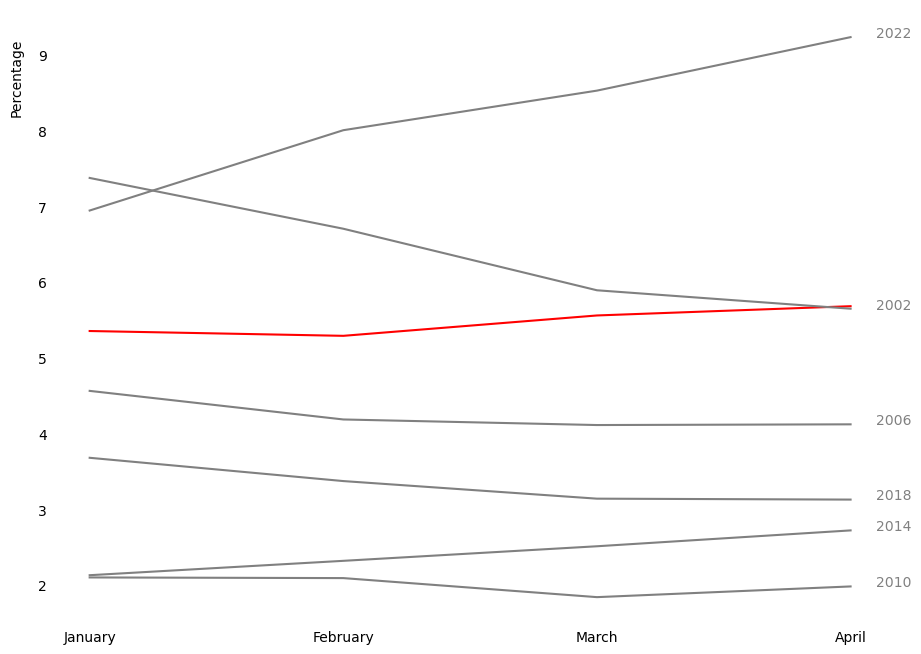

In [6]:
plot(series_annual, presidents_last_years)

### Annual core 15 comparison

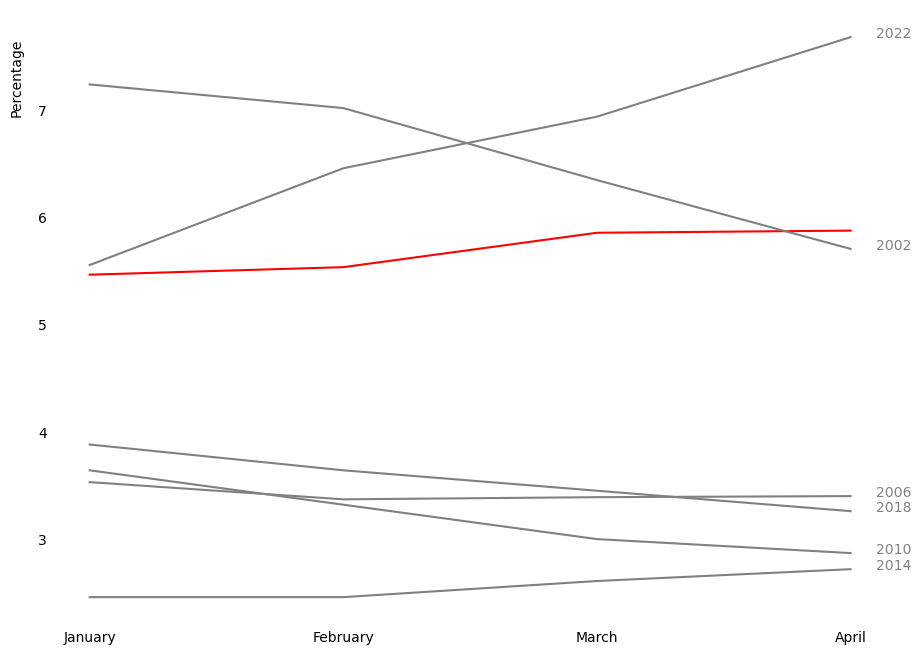

In [7]:
plot(series_core_15, presidents_last_years)

### Annual core 20 comparison

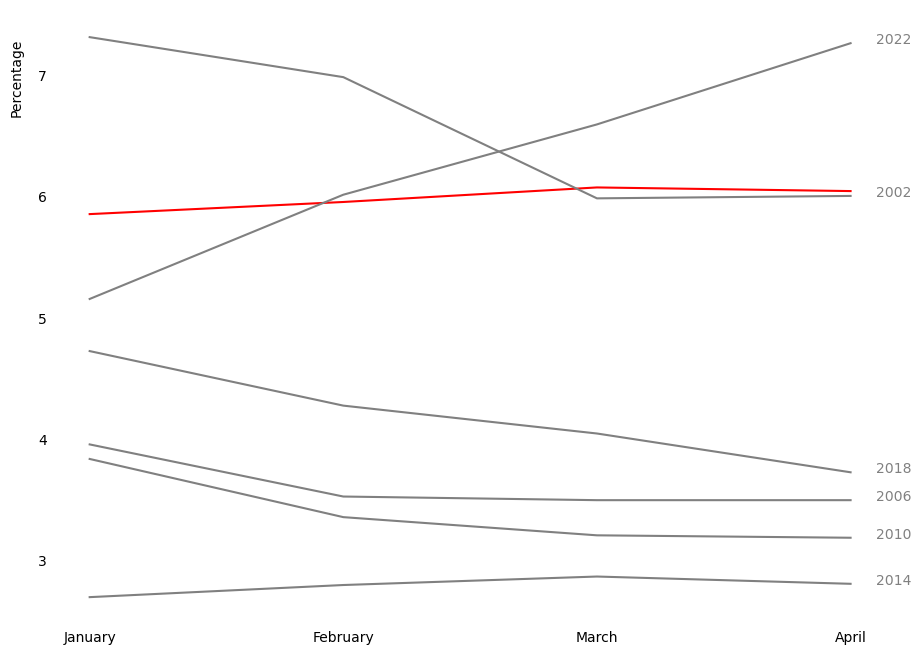

In [8]:
plot(series_core_20, presidents_last_years)

## year to date comparison

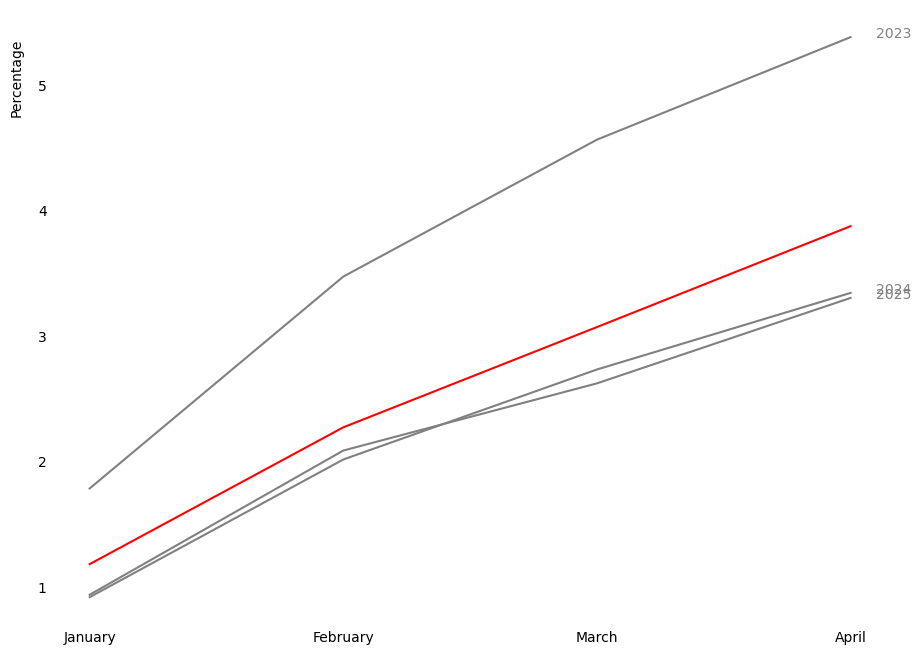

In [9]:
plot(series_ytd, petro_year)

## Monthly comparision

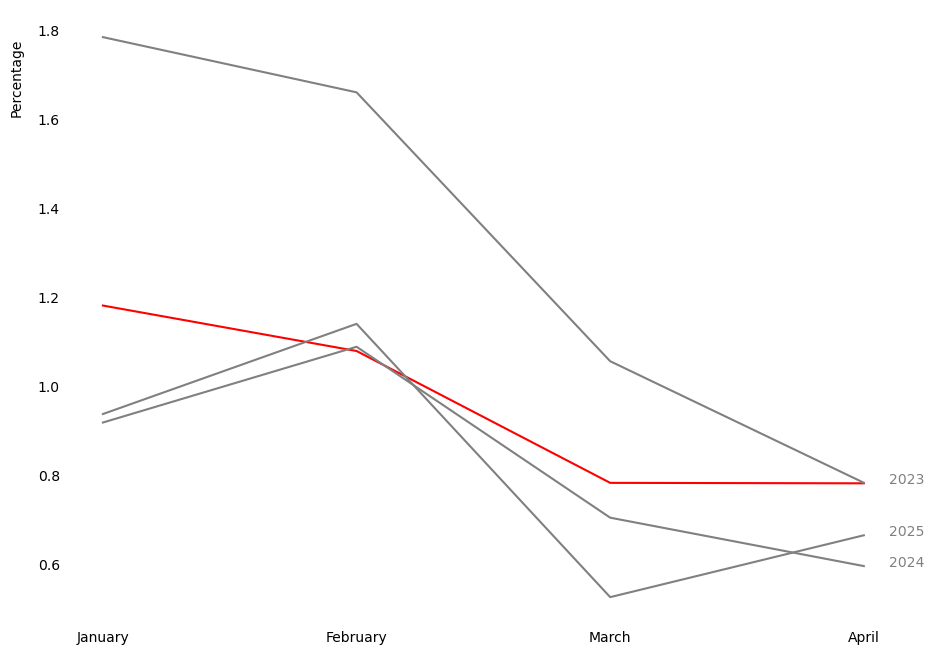

In [10]:
plot(series_monthly, petro_year)